In [428]:
import numpy as np
import scipy #Library for signal analysis
import matplotlib.pyplot as plt #Plot
import numpy as np #Operations
import cv2 #Read images and do operations
import IPython.display as ipd
import numpy.random #For generating noise
import copy

from copy import deepcopy

from numpy import linalg

from scipy import signal
from scipy.io import wavfile #Read wavfiles
from scipy.signal import welch,stft,istft #Get power density estimated, short fourier transform

audio_file = 'music.wav'

def read_file_PROPERLY(wavfile_name):
    samplerate_music, data_music = wavfile.read(wavfile_name) #Read the file
    data_music=data_music.astype(np.double)/2**15
    return samplerate_music,data_music

fs, data = read_file_PROPERLY(audio_file)#wavfile.read(audio_file)

Ls = len(data)

print('Setting up the frame parameters\n')


inputSDR = 7


wtype = 'hann'
w = 8192
a = int(w / 4)
M = 2*w

shrinkage = 'EW'
print('Setting up shrinkage operator: %s\n', shrinkage)

verbose = True


Setting up the frame parameters

Setting up shrinkage operator: %s
 EW


In [429]:
ipd.Audio(data, rate=fs)

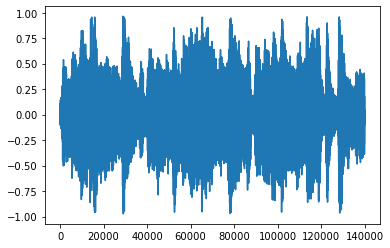

In [430]:
plt.plot(data)

In [431]:
def clip_audio(data, thresh):
    data = data.copy()
    masks = {}
    masks['Mh'] = (data > thresh)
    masks['Ml'] = (data < -thresh)
    masks['Mr'] = (data > thresh) | (data < -thresh)
    data[masks['Mr']] = thresh
    return data, masks

In [432]:
theta = 0.6#15000

data_clipped, masks = clip_audio(data, theta)

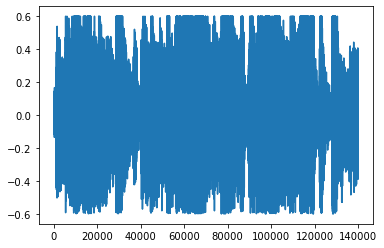

In [433]:
plt.plot(data_clipped)

In [434]:
ipd.Audio(data_clipped, rate=fs)

In [435]:
data_r = np.zeros((Ls,))
data_r[masks['Mr']] = data_clipped[masks['Mr']]

In [436]:
data_c = np.zeros(Ls)
data_c[masks['Mh']] = theta;
data_c[masks['Ml']] = -theta;

In [437]:
from ltfatpy.gabor.gabwin import gabwin
from ltfatpy.gabor.gabtight import gabtight
from ltfatpy.gabor.dgtreal import dgtreal
from ltfatpy.gabor.idgtreal import idgtreal

In [438]:

g = gabtight({'name': 'hann', 'M':w}, a, M)

g = (g, {})

data_clipped_float = data_clipped.astype('float64')

G_clip = dgtreal(data_clipped_float, g[0], a, M)
print(len(G_clip))
[nf,nt] = G_clip[0].shape


def analysis(x):
    return dgtreal(x,g[0],a,M)[0]
    
def synthesis(x):
    return idgtreal(x,g[0],a,M,Ls)[0]

3


In [439]:
nt

72

In [440]:
# if shrinkage == 'L':
#     shrink = {'type':'l', 'lambda':1e-4, 'mu':1, 'glabel':'time','neigh':1, 'center':[1, 1], 'expo':1,'orth':0}
# elif shrinkage == 'WGL':
#     shrink = {'type':'l', 'lambda':1e-4, 'mu':1, 'glabel':'time','neigh':np.ones((3,7)), 'center':[2,4], 'expo':1,'orth':0}
# elif shrinkage == 'EW':
# shrink = {'type': 'l', 'lambda': 1e-4, 'mu': 1, 'glabel': 'time','neigh': 1, 'center': [1, 1], 'expo': 2,'orth':0}
# elif shrinkage == 'PEW':
shrink = {'type': 'l', 'lambda': 1e-4, 'mu': 1, 'glabel': 'time','neigh': np.ones((3,7)), 'center': [2,4], 'expo': 2,'orth':0}
# else:
#     error('Invalid shrinkage operator!')

In [441]:
def maximum(x):
    return max(0,x)

def lasso_threshold(coeff,lambd):
    first = lambd/abs(coeff)
    maximun_v = np.vectorize(maximum)
    second = maximun_v(first)
    second=second.astype('complex128')
    return second

In [442]:
kok = np.arange(0,16).reshape((4,-1))
kok, kok[0:3, 0:3]

(array([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11],
        [12, 13, 14, 15]]),
 array([[ 0,  1,  2],
        [ 4,  5,  6],
        [ 8,  9, 10]]))

In [445]:
import math 

def sdr (u, v):

    sdr_val = 20*np.log10(np.linalg.norm(u)/np.linalg.norm(u-v))

    return sdr_val

def l_threshfunc(W, lama):
    threshfunc = lama/W
    return threshfunc
    
from scipy.signal import convolve2d

def conv2(x, y, mode='same'):
    return convolve2d(x, y, mode=mode)#np.rot90(convolve2d(np.rot90(x, 2), np.rot90(y, 2), mode=mode), 2)

def pers_weights(G, neigh, center):
    M, N = G.shape
    MM, NN = neigh.shape
#     print(MM, NN)
    c1 = center[0]
    c2 = center[1]
    cc1 = math.ceil(MM/2) 
    cc2 = math.ceil(NN/2) #% take actual centers of neighborhood
    neigh = neigh/np.linalg.norm(neigh[:],1) #% normalize neighborhood weights

#     % check neighborhood - center point relations
    if center[0] > MM:
        print('This cannot be right... Check your center point.')
        return
    elif center[1] > NN:
        print('This cannot be right... Check your center point.')
        return
    

    X2 = np.zeros((M+MM-1, N+NN-1)) #% make larger matrix with mirrowed borders:
#     print(X2[c1:M+c1, c2:N+c2].shape, G.shape)
    X2[c1-1: M+c1-1, c2-1:N+c2-1] = np.power(np.abs(G), 2) #% put x in the middle of x2
#     print(X2[:, :c2-1].shape,  np.fliplr(X2[:, c2-1:2*(c2-1)]).shape)
    X2[:, :c2-1] =  np.fliplr(X2[:, c2-1:2*(c2-1)]) #% left border
#     print(X2[:, N+c2-1:].shape, np.fliplr(X2[:, N - NN+2*c2:N+c2]).shape, X2.shape, c2)
    X2[:, N+c2-1:] = np.fliplr(X2[:, N - NN +2*c2 - 1: N+c2-1]) #% right border
#     print(X2[1:c1-1, :].shape,  np.flipud(X2[c1:2*(c1-1), :]).shape, X2.shape, c2)
    X2[:c1-1, :] = np.flipud(X2[c1-1:2*(c1-1), :]) #% upper border
    X2[M+c1-1:, :] = np.flipud(X2[M-MM + 2*c1 -1: M+c1-1, :])# % lower border

#     % compute the stuff via convolution!
    X2 = conv2(X2, neigh, 'same')
    W = X2[cc1-1: M + cc1 - 1, cc2-1: N + cc2 -1] #% resize matrix 
    W = np.sqrt(W) #% should be included for WGL!
    return W


def gen_thresh(G, shrink):
    # % computation of persistence weights
    W = pers_weights(G, shrink['neigh'], shrink['center'])

    # % computation of threshold function value
    TF = l_threshfunc(W, shrink['lambda'])#lasso_threshold(W, shrink['lambda'])#

    # % compute shrinkage
    TF[np.isinf(TF)] = 0
    Gs = 1 - np.power(TF, shrink['expo'])
    GGs = Gs*(Gs>0)
    
    
#     print(W.shape, Gs.shape, TF.shape, GGs.shape)
    Gs = G*GGs

    return Gs

ModuleNotFoundError: No module named 'libsmop'

In [446]:
from tqdm import tqdm
Gdeclip = np.zeros((nf,nt), dtype=np.complex128)
GdeclipZ = Gdeclip

number_lambdas = 5
inner_iterations = 500
delta = 1e-4
iter_cnt = 0

init_sdr = sdr(data, data_clipped)

# dSDR_process = np.empty(number_lambdas*inner_iterations)
# dSDR_process[:] = np.NaN
data_rec = data_clipped

for lamba in tqdm(np.logspace(-1,-4,number_lambdas)):
    shrink['lambda'] = lamba
    for k in range(inner_iterations):

        data_rec_old = data_rec.copy()
        iter_cnt = iter_cnt + 1

#         % forward step
        GdeclipOLD = Gdeclip
    
#         print(GdeclipZ)

        xdeclipZ = synthesis(GdeclipZ)
        
        if np.isnan(np.min(xdeclipZ)):
            raise Exception('np.isnan(np.min(xdeclipZ))')

        r1 = np.zeros(Ls)
#         print(xdeclipZ[masks['Mr']])
        r1[masks['Mr']] = data_r[masks['Mr']] - xdeclipZ[masks['Mr']]

        grad1 = -analysis(r1)

        r2 = np.zeros(Ls)
        r2[masks['Mh']] = data_c[masks['Mh']] - xdeclipZ[masks['Mh']]
        r2[masks['Ml']] = data_c[masks['Ml']] - xdeclipZ[masks['Ml']]

        r2[np.abs(xdeclipZ)>theta] = 0
        grad2 = -analysis(r2)


        GdeclipZ = GdeclipZ - grad1 - grad2
        
        if np.isnan(np.min(GdeclipZ)):
            raise Exception('GdeclipZ')
            

#         % thresholding step
        Gdeclip = gen_thresh(GdeclipZ, shrink) #lasso_threshold(GdeclipZ, lamba)#
        
        if np.isnan(np.min(GdeclipZ)):
            raise Exception('Gdeclip')

#         % relaxation step
        GdeclipZ = Gdeclip + (k-1)/(k+5) * (Gdeclip - GdeclipOLD)



        data_rec = synthesis(Gdeclip)
        
        if np.isnan(np.min(data_rec)):
            raise Exception('Gdeclip')
#         print(data_rec)
        dif = np.linalg.norm(data_rec_old - data_rec)
        if dif  < delta:
            break
        


        if verbose:
            sdr_rec = sdr(data, data_rec)
            print(sdr_rec, init_sdr, dif)
        

    


  0%|          | 0/5 [00:00<?, ?it/s]/home/mykola/anaconda3/envs/nets/lib/python3.6/site-packages/ipykernel_launcher.py:10: RuntimeWarning: divide by zero encountered in true_divide
  # Remove the CWD from sys.path while we load stuff.


0.5453771544796973 6.185013002218294 79.9631645628722
0.5682569391982295 6.185013002218294 14.923853291985495
0.7119636699821813 6.185013002218294 6.932151605978668
0.7656263991607805 6.185013002218294 3.805151588320459
0.814285064309457 6.185013002218294 3.5819864608406045
0.8428157318070506 6.185013002218294 3.1708178437773338
0.8590517975350846 6.185013002218294 2.9716208532753874
0.8647413156334766 6.185013002218294 2.798901247008691
0.8641529533037406 6.185013002218294 2.6946033266201135
0.8564376568075999 6.185013002218294 2.5301802911654367
0.8435182364849552 6.185013002218294 2.40804936359212
0.8258370330546134 6.185013002218294 2.2861429912020705
0.8038680062920456 6.185013002218294 2.1975027574356436
0.7791612444186122 6.185013002218294 2.092652372341294
0.7521815934706602 6.185013002218294 2.0585094306262715
0.7246750024695114 6.185013002218294 2.0106285424569816
0.6940281930744381 6.185013002218294 1.951878143502074
0.6616772983436502 6.185013002218294 1.8548960303065296
0.

  0%|          | 0/5 [00:15<?, ?it/s]

-1.6153084040687802 6.185013002218294 0.46229643435040535


KeyboardInterrupt: 

In [398]:
ipd.Audio(data_rec, rate=fs)

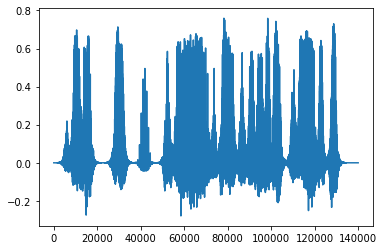

In [399]:
plt.plot(data_rec)

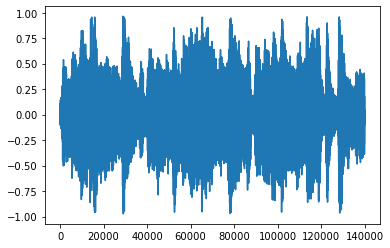

In [373]:
plt.plot(data)